# Treinamento de modelo sobre a ABT

Este notebook treina uma regressão logística para prever `target` a partir de `DataPipeline/abt.csv`. O pré-processamento é aprendido somente com os dados de treino e fica incorporado ao artefato final.

In [1]:
# As dependências já estão instaladas em data-platform/.venv.
# No VS Code, selecione esse ambiente como kernel antes de executar.

In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
DECISION_THRESHOLD = 0.50
CV_FOLDS = 5

## 1. Carregamento da ABT

A busca funciona ao executar o notebook pela pasta `Model`, por `data-platform` ou pela raiz do repositório.

In [3]:
project_root = Path.home() / "Desktop/ProjetoFinalIA_Andre/ProjetoFinalPosFIA"
csv_candidates = [
    project_root / "data-platform/DataPipeline/abt.csv",
    Path("../DataPipeline/abt.csv"),
    Path("DataPipeline/abt.csv"),
    Path("data-platform/DataPipeline/abt.csv"),
]

ABT_PATH = None
searched = []
for path in csv_candidates:
    try:
        candidate = path if path.is_absolute() else path.absolute()
        searched.append(str(candidate))
        if candidate.is_file():
            ABT_PATH = candidate
            break
    except OSError as error:
        searched.append(f"{path} (indisponível: {error})")

if ABT_PATH is None:
    raise FileNotFoundError("abt.csv não encontrado. Caminhos pesquisados:\n" + "\n".join(searched))

df = pd.read_csv(ABT_PATH, encoding="utf-8")
print(f"Arquivo: {ABT_PATH}")
print(f"ABT carregada: {df.shape[0]:,} linhas e {df.shape[1]} colunas")
display(df.head())

Arquivo: /Users/romuloarrivabene/Desktop/ProjetoFinalIA_Andre/ProjetoFinalPosFIA/data-platform/DataPipeline/abt.csv
ABT carregada: 307,511 linhas e 34 colunas


,sk_id_curr,target,ext_source_2,region_rating_client,region_rating_client_w_city,days_last_phone_change,days_id_publish,days_registration,reg_city_not_work_city,reg_city_not_live_city,...,name_education_type,code_gender,age,years_employed,prev_refused_rate,bureau_avg_days_credit,bureau_last_days_credit,bureau_active_rate,bureau_active_count,bureau_closed_rate
0,100002,1,0.262949,2,2,-1134.0,-2120,-3648.0,0,0,...,Secondary / secondary special,M,25.902806,1.744011,0.000000,-874.00,-103.0,0.25,2.0,0.75
1,100003,0,0.622246,1,1,-828.0,-291,-1186.0,0,0,...,Higher education,F,45.900068,3.252567,0.000000,-1400.75,-606.0,0.25,1.0,0.75
2,100004,0,0.555912,2,2,-815.0,-2531,-4260.0,0,0,...,Secondary / secondary special,M,52.145106,0.616016,0.000000,-867.00,-408.0,0.00,0.0,1.00
3,100006,0,0.650442,2,2,-617.0,-2437,-9833.0,0,0,...,Secondary / secondary special,F,52.032854,8.320329,0.111111,NaN,NaN,NaN,NaN,NaN
4,100007,0,0.322738,2,2,-1106.0,-3458,-4311.0,1,0,...,Secondary / secondary special,M,54.570842,8.317591,0.000000,-1149.00,-1149.0,0.00,0.0,1.00


## 2. Preparação das variáveis

O identificador `sk_id_curr` não participa do treinamento. Valores infinitos são tratados como ausentes e imputados dentro do pipeline.

In [4]:
required_columns = {"sk_id_curr", "target"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes na ABT: {sorted(missing_columns)}")

df_model = df.replace([np.inf, -np.inf], np.nan).copy()
X = df_model.drop(columns=["target", "sk_id_curr"])
y = pd.to_numeric(df_model["target"], errors="raise").astype(int)

empty_columns = X.columns[X.isna().all()].tolist()
X = X.drop(columns=empty_columns)

print(f"Variáveis explicativas: {X.shape[1]}")
print(f"Colunas totalmente vazias removidas: {empty_columns}")
print("Distribuição do target (%):")
display(y.value_counts(normalize=True).mul(100).round(2).sort_index())

Variáveis explicativas: 32
Colunas totalmente vazias removidas: []
Distribuição do target (%):


target
0    91.93
1     8.07
Name: proportion, dtype: float64

## 3. Separação entre treino e teste

A estratificação mantém aproximadamente a mesma proporção de inadimplentes nos dois conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"Numéricas: {len(numeric_features)} | Categóricas: {len(categorical_features)}")

Treino: 246,008 | Teste: 61,503
Numéricas: 27 | Categóricas: 5


## 4. Pré-processamento e otimização de hiperparâmetros

Medianas, escalas e categorias são aprendidas somente dentro de cada partição de treino da validação cruzada. A busca compara intensidades de regularização (`C`) e o uso de `class_weight='balanced'`, selecionando a combinação com maior ROC AUC médio. O conjunto de teste permanece isolado até a avaliação final.

In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

base_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=100,
        solver="newton-cholesky",
        random_state=RANDOM_STATE,
    )),
])

# Mantém a configuração anterior como referência para comparação.
baseline_model = clone(base_model)
baseline_model.fit(X_train, y_train)

param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "classifier__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)
search.fit(X_train, y_train)
model = search.best_estimator_

print(f"Melhores hiperparâmetros: {search.best_params_}")
print(f"ROC AUC médio na validação cruzada: {search.best_score_:.4f}")

cv_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    [["rank_test_score", "mean_test_score", "std_test_score", "mean_train_score", "param_classifier__C", "param_classifier__class_weight"]]
)
display(cv_results.head(10))

Melhores hiperparâmetros: {'classifier__C': 100.0, 'classifier__class_weight': 'balanced'}
ROC AUC médio na validação cruzada: 0.7245


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_classifier__C,param_classifier__class_weight
9,1,0.724505,0.002753,0.726681,100.00,balanced
7,2,0.724503,0.002751,0.726680,10.00,balanced
5,3,0.724486,0.002741,0.726666,1.00,balanced
3,4,0.724473,0.002694,0.726611,0.10,balanced
8,5,0.724383,0.002677,0.726372,100.00,NaN
6,6,0.724375,0.002677,0.726366,10.00,NaN
1,7,0.724364,0.002602,0.726236,0.01,balanced
2,8,0.724362,0.002590,0.726227,0.10,NaN
4,9,0.724356,0.002649,0.726340,1.00,NaN
0,10,0.723610,0.002466,0.725048,0.01,NaN


## 5. Avaliação

ROC AUC mede a capacidade geral de ordenação. Average Precision é especialmente útil para a classe inadimplente, que é minoritária.

,modelo,roc_auc,average_precision
0,Configuração anterior,0.7301,0.2113
1,Modelo otimizado,0.7300,0.2115



Relatório de classificação (limiar = 0.50):
              precision    recall  f1-score   support

           0     0.9583    0.6793    0.7951     56538
           1     0.1538    0.6636    0.2497      4965

    accuracy                         0.6780     61503
   macro avg     0.5561    0.6715    0.5224     61503
weighted avg     0.8934    0.6780    0.7510     61503



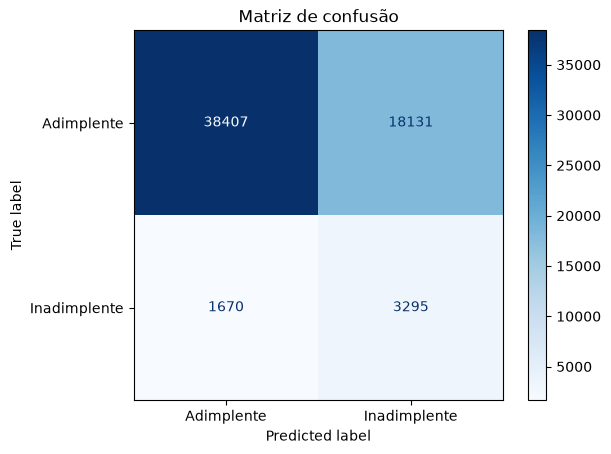

In [7]:
baseline_probability = baseline_model.predict_proba(X_test)[:, 1]
y_probability = model.predict_proba(X_test)[:, 1]
y_prediction = (y_probability >= DECISION_THRESHOLD).astype(int)

baseline_roc_auc = roc_auc_score(y_test, baseline_probability)
baseline_average_precision = average_precision_score(y_test, baseline_probability)
roc_auc = roc_auc_score(y_test, y_probability)
average_precision = average_precision_score(y_test, y_probability)

comparison = pd.DataFrame({
    "modelo": ["Configuração anterior", "Modelo otimizado"],
    "roc_auc": [baseline_roc_auc, roc_auc],
    "average_precision": [baseline_average_precision, average_precision],
})
display(comparison.round(4))
print(f"\nRelatório de classificação (limiar = {DECISION_THRESHOLD:.2f}):")
print(classification_report(y_test, y_prediction, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues",
)
plt.title("Matriz de confusão")
plt.show()

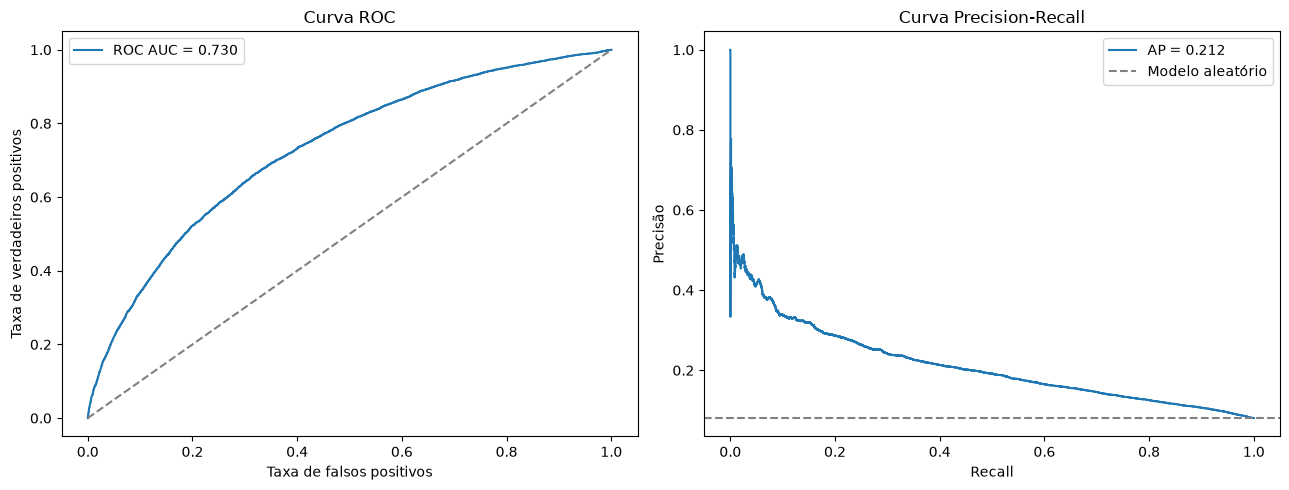

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_probability)
precision, recall, _ = precision_recall_curve(y_test, y_probability)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Curva ROC", xlabel="Taxa de falsos positivos", ylabel="Taxa de verdadeiros positivos")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP = {average_precision:.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Modelo aleatório")
axes[1].set(title="Curva Precision-Recall", xlabel="Recall", ylabel="Precisão")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Variáveis mais influentes

Coeficientes indicam associação com a pontuação de inadimplência, não causalidade.

In [9]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]
importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients),
}).sort_values("absolute_coefficient", ascending=False)

display(importance.head(25))

,feature,coefficient,absolute_coefficient
87,categorical__organization_type_XNA,4.883990,4.883990
90,categorical__name_income_type_Pensioner,-3.503727,3.503727
100,categorical__code_gender_infrequent_sklearn,-2.489652,2.489652
92,categorical__name_income_type_Working,1.775074,1.775074
91,categorical__name_income_type_State servant,1.681999,1.681999
88,categorical__name_income_type_Commercial assoc...,1.666842,1.666842
89,categorical__name_income_type_Other_low_freq,-1.620188,1.620188
99,categorical__code_gender_M,1.385723,1.385723
93,categorical__name_education_type_Academic degree,-1.301301,1.301301
18,numeric__amt_goods_price,-1.161558,1.161558


## 7. Persistência do modelo

O artefato contém pré-processamento, classificador, limiar e metadados necessários para inferência.

In [10]:
ARTIFACT_DIR = ABT_PATH.parent.parent / "Model/artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "logistic_regression_abt.joblib"

artifact = {
    "model": model,
    "decision_threshold": DECISION_THRESHOLD,
    "input_features": X.columns.tolist(),
    "metrics": {
        "roc_auc": roc_auc,
        "average_precision": average_precision,
        "cv_roc_auc": search.best_score_,
    },
    "best_params": search.best_params_,
    "cv_folds": CV_FOLDS,
}
joblib.dump(artifact, MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH.resolve()}")

Modelo salvo em: /Users/romuloarrivabene/Desktop/ProjetoFinalIA_Andre/ProjetoFinalPosFIA/data-platform/Model/artifacts/logistic_regression_abt.joblib
